### Final Task ITS Hackathon DSC 2026

#### The aims of this project is to identify bank loans performance and risk analysis

Import dataset

Dataset used: 
- customers.csv
- accounts.csv
- branches.csv
- loans.csv
- loan_payments.csv

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from pathlib import Path
from datetime import datetime

Load all dataset

In [2]:
customer_data = pd.read_csv('./its-ssc-hackathon-2026/customers.csv',engine='python')
account_data = pd.read_csv('./its-ssc-hackathon-2026/accounts.csv',engine='python')
branch_data = pd.read_csv('./its-ssc-hackathon-2026/branches.csv',engine='python')
loan_data = pd.read_csv('./its-ssc-hackathon-2026/loans.csv',engine='python')
loan_payment_data = pd.read_csv('./its-ssc-hackathon-2026/loan_payments.csv',engine='python')

### Section 1

Viewing and Finding Insight from Customers Data

In [3]:
customer_data

,customer_id,name,gender,date_of_birth,city,state,phone,email,occupation,annual_income,join_date,credit_score
0,1,Pooja Garcia,Male,1987-12-11,Ahmedabad,Gujarat,9562078082,customer0@mailbank.com,Retired,200025,2018-02-23,690
1,2,Anjali Kapoor,Female,1965-12-18,Lucknow,Uttar Pradesh,9599825073,customer1@mailbank.com,Salaried - Government,1865003,2020-11-08,672
2,3,James Smith,Female,1979-03-12,Chandigarh,Punjab,9572599111,customer2@mailbank.com,Salaried - Government,1709141,2007-04-22,422
3,4,Susan Joshi,Male,1996-11-07,Nagpur,Maharashtra,9364883923,customer3@mailbank.com,Salaried - Private,1917060,2009-01-18,498
4,5,Kiran Mehta,Male,1952-02-17,Lucknow,Uttar Pradesh,9753361420,customer4@mailbank.com,Freelancer,2398864,2019-01-21,690
...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59996,Priya Desai,Female,1988-08-02,Ahmedabad,Gujarat,9307135414,customer59995@mailbank.com,Self Employed,530569,2017-07-15,836
59996,59997,Susan Verma,Male,1985-10-26,Chennai,Tamil Nadu,9172933389,customer59996@mailbank.com,Freelancer,824262,2024-04-17,801
59997,59998,Meera Rodriguez,Male,1965-05-05,Nagpur,Maharashtra,9515112666,customer59997@mailbank.com,Salaried - Private,1224910,2008-07-12,754
59998,59999,Jennifer Desai,Male,2003-11-08,Jaipur,Rajasthan,9956126472,customer59998@mailbank.com,Business Owner,2906687,2006-11-12,638


In [4]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    60000 non-null  int64 
 1   name           60000 non-null  object
 2   gender         60000 non-null  object
 3   date_of_birth  60000 non-null  object
 4   city           60000 non-null  object
 5   state          60000 non-null  object
 6   phone          60000 non-null  int64 
 7   email          60000 non-null  object
 8   occupation     60000 non-null  object
 9   annual_income  60000 non-null  int64 
 10  join_date      60000 non-null  object
 11  credit_score   60000 non-null  int64 
dtypes: int64(4), object(8)
memory usage: 5.5+ MB


Checking missing values on the Customers data

<Figure size 1000x600 with 0 Axes>

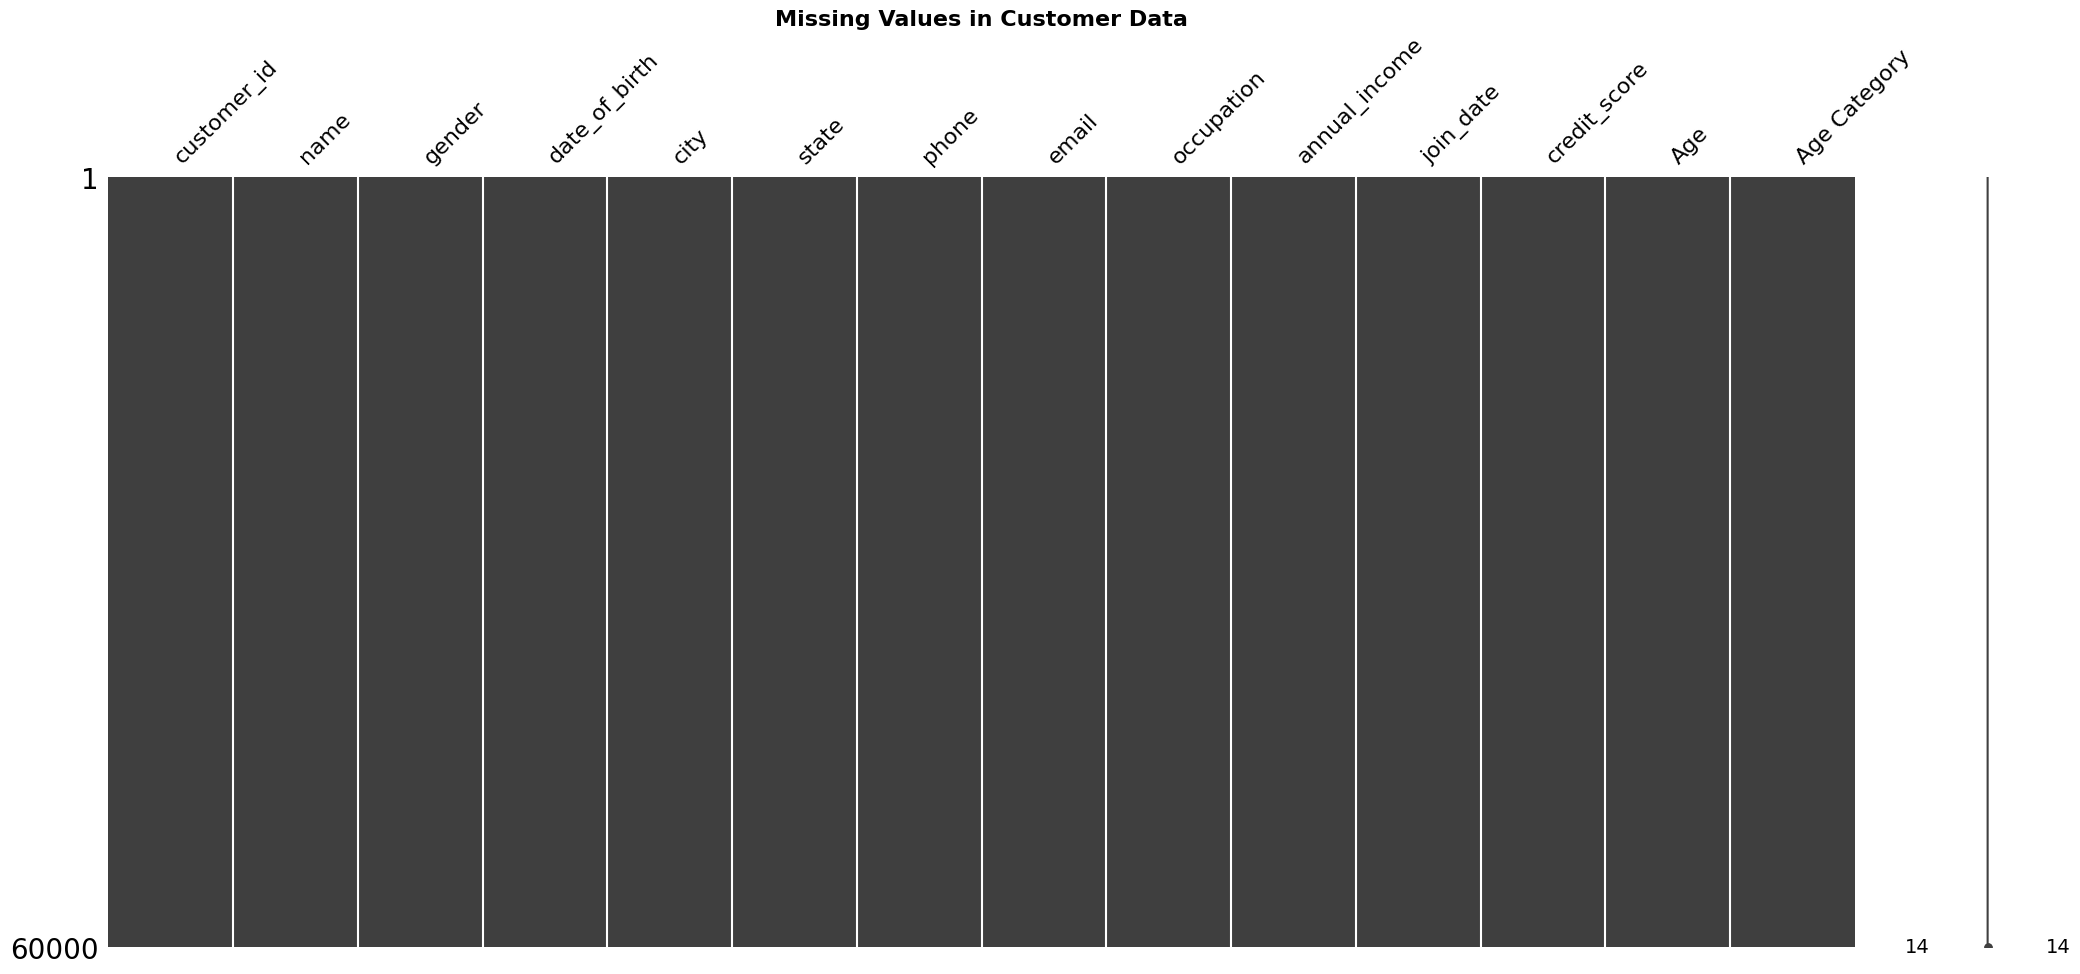

In [61]:
plt.figure(figsize=(10, 6))
msno.matrix(customer_data)
plt.title('Missing Values in Customer Data', fontsize=16, fontweight='bold')
plt.show()

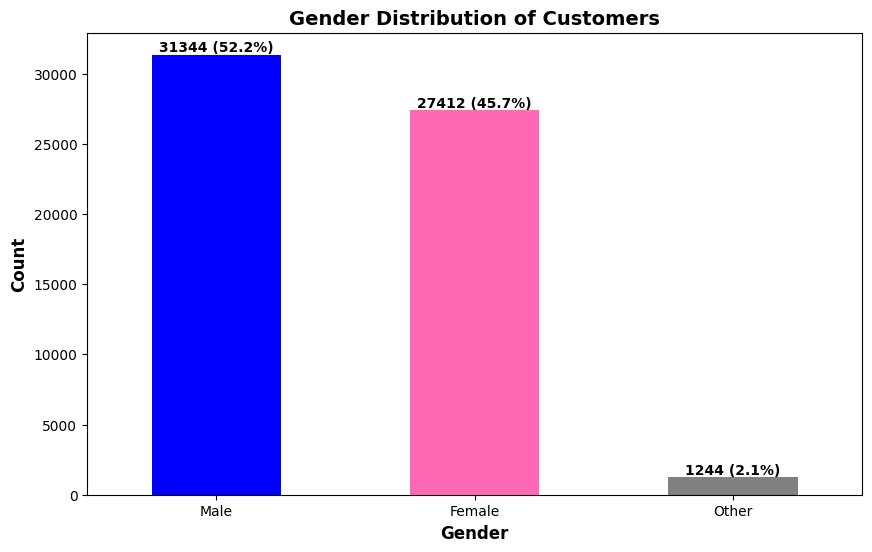

In [6]:
gender = customer_data['gender'].value_counts()

gender.plot(kind='bar', color=['blue', 'hotpink', 'gray'], figsize=(10, 6))
autolabels = [f'{count} ({count / gender.sum() * 100:.1f}%)' for count in gender]

for i, (bar, label) in enumerate(zip(gender.index, autolabels)):
    plt.text(i, gender[bar] + 0.5, label, ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Gender', fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Gender Distribution of Customers', fontsize=14, fontweight='bold')

plt.show()

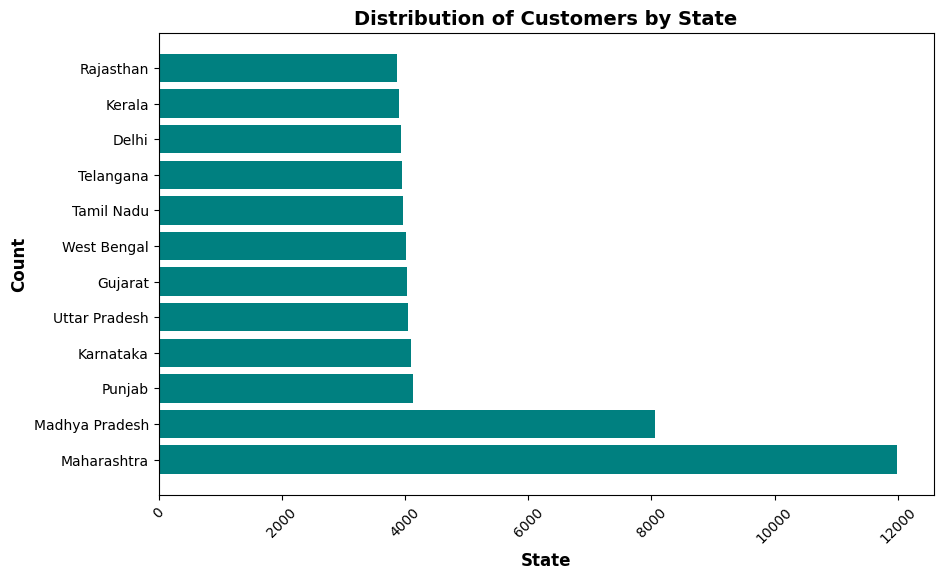

In [7]:
plt.figure(figsize=(10, 6))
plt.barh(customer_data['state'].value_counts().index, customer_data['state'].value_counts().values, color='teal')
plt.xlabel('State', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Customers by State', fontsize=14, fontweight='bold')

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

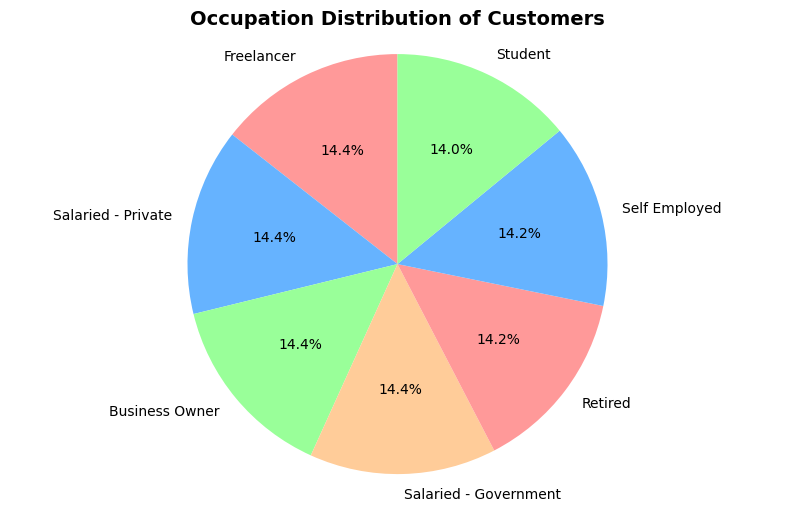

In [8]:
plt.figure(figsize=(10, 6))
plt.pie(customer_data['occupation'].value_counts(), labels=customer_data['occupation'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Occupation Distribution of Customers', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

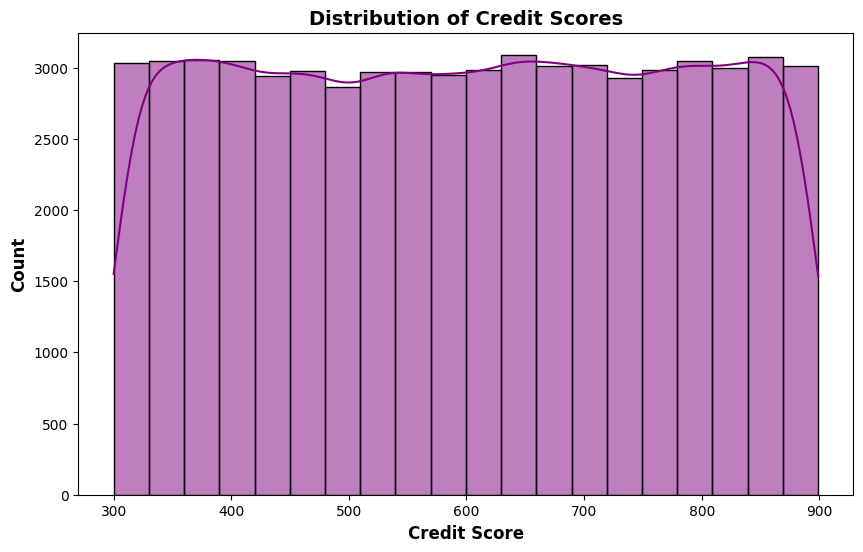

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(customer_data['credit_score'], bins=20, kde=True, color='purple')
plt.xlabel('Credit Score', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Credit Scores', fontsize=14, fontweight='bold')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

In [10]:
customer_data['Age'] = (datetime.now() - pd.to_datetime(customer_data['date_of_birth'])).dt.days // 365

In [11]:
customer_data

,customer_id,name,gender,date_of_birth,city,state,phone,email,occupation,annual_income,join_date,credit_score,Age
0,1,Pooja Garcia,Male,1987-12-11,Ahmedabad,Gujarat,9562078082,customer0@mailbank.com,Retired,200025,2018-02-23,690,38
1,2,Anjali Kapoor,Female,1965-12-18,Lucknow,Uttar Pradesh,9599825073,customer1@mailbank.com,Salaried - Government,1865003,2020-11-08,672,60
2,3,James Smith,Female,1979-03-12,Chandigarh,Punjab,9572599111,customer2@mailbank.com,Salaried - Government,1709141,2007-04-22,422,47
3,4,Susan Joshi,Male,1996-11-07,Nagpur,Maharashtra,9364883923,customer3@mailbank.com,Salaried - Private,1917060,2009-01-18,498,29
4,5,Kiran Mehta,Male,1952-02-17,Lucknow,Uttar Pradesh,9753361420,customer4@mailbank.com,Freelancer,2398864,2019-01-21,690,74
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,59996,Priya Desai,Female,1988-08-02,Ahmedabad,Gujarat,9307135414,customer59995@mailbank.com,Self Employed,530569,2017-07-15,836,38
59996,59997,Susan Verma,Male,1985-10-26,Chennai,Tamil Nadu,9172933389,customer59996@mailbank.com,Freelancer,824262,2024-04-17,801,40
59997,59998,Meera Rodriguez,Male,1965-05-05,Nagpur,Maharashtra,9515112666,customer59997@mailbank.com,Salaried - Private,1224910,2008-07-12,754,61
59998,59999,Jennifer Desai,Male,2003-11-08,Jaipur,Rajasthan,9956126472,customer59998@mailbank.com,Business Owner,2906687,2006-11-12,638,22


In [12]:
categories = []
for i in customer_data['Age']:
    if i < 30:
        categories.append("Young")
    elif 30 <= i < 50:
        categories.append("Middle-aged")
    else:
        categories.append("Senior")

customer_data['Age Category'] = categories

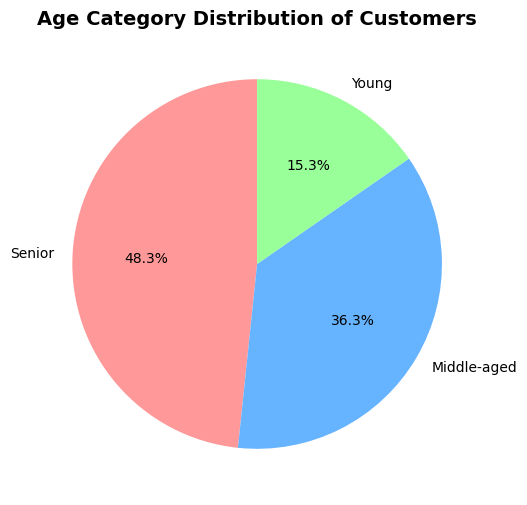

In [13]:
plt.figure(figsize=(10, 6))
plt.pie(customer_data['Age Category'].value_counts(), labels=customer_data['Age Category'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Age Category Distribution of Customers', fontsize=14, fontweight='bold')
plt.show()

### Section 2

Viewing and Finding Insight from Accounts data

In [14]:
account_data

,account_id,customer_id,branch_id,account_type,balance,open_date,status
0,1,11749,141,Current,95902.00,2019-10-20,Active
1,2,47716,43,Current,13261.61,2026-02-03,Active
2,3,56143,90,Savings,26495.92,2020-10-19,Active
3,4,29193,113,Salary,74682.72,2012-02-22,Active
4,5,49907,28,Current,40419.01,2007-01-03,Active
...,...,...,...,...,...,...,...
94995,94996,43366,38,Fixed Deposit,66228.51,2012-03-18,Closed
94996,94997,50856,12,Current,39854.55,2011-10-21,Active
94997,94998,8593,68,Current,9310.24,2021-03-22,Active
94998,94999,49233,107,Fixed Deposit,13110.16,2009-10-16,Active


In [15]:
account_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   account_id    95000 non-null  int64  
 1   customer_id   95000 non-null  int64  
 2   branch_id     95000 non-null  int64  
 3   account_type  95000 non-null  object 
 4   balance       95000 non-null  float64
 5   open_date     95000 non-null  object 
 6   status        95000 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 5.1+ MB


Checking missing values on the Account data

<Figure size 1000x600 with 0 Axes>

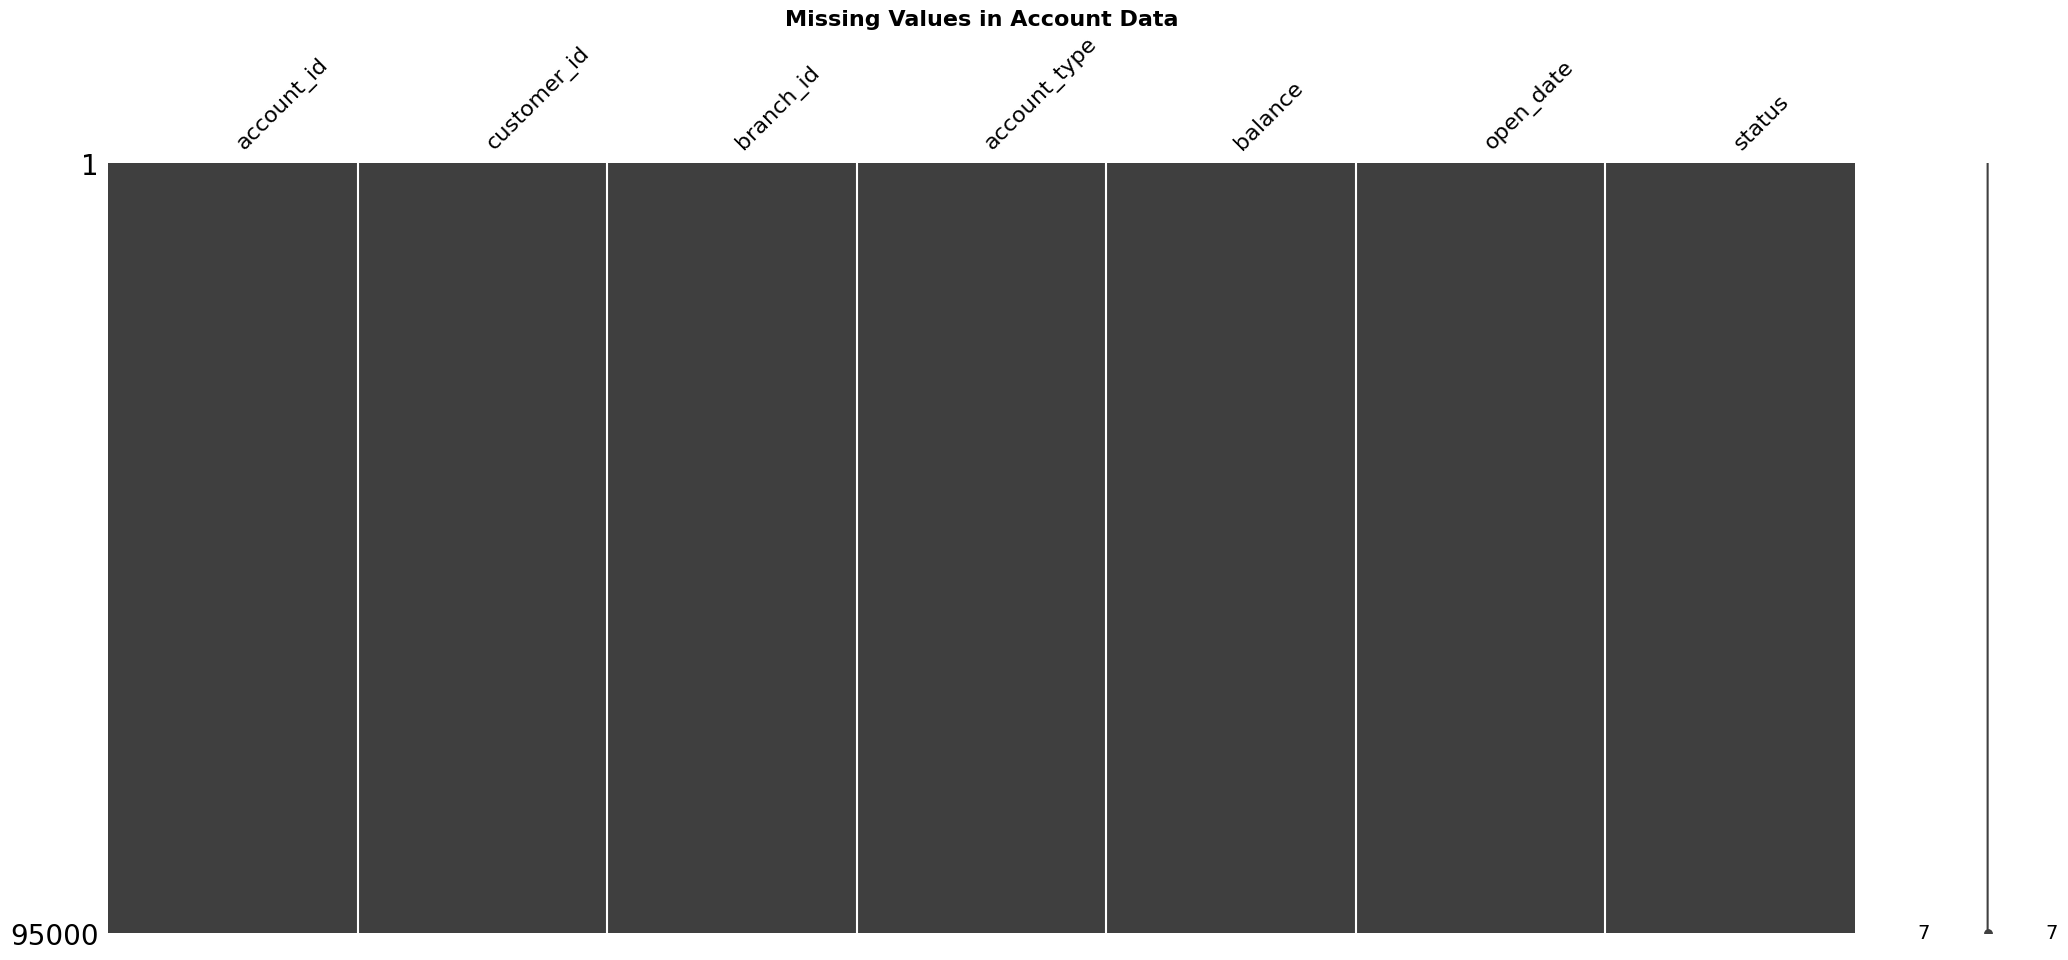

In [16]:
plt.figure(figsize=(10, 6))
msno.matrix(account_data)
plt.title('Missing Values in Account Data', fontsize=16, fontweight='bold')
plt.show()

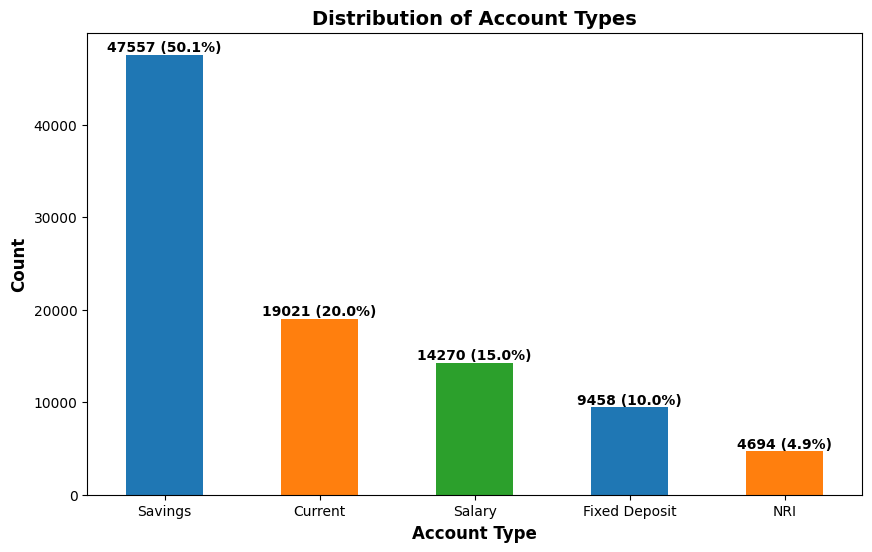

In [17]:
account_data['account_type'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'], figsize=(10, 6))

for i, (bar, label) in enumerate(zip(account_data['account_type'].value_counts().index, account_data['account_type'].value_counts().values)):
    plt.text(i, label + 0.5, f'{label} ({label / account_data.shape[0] * 100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Account Type', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Account Types', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

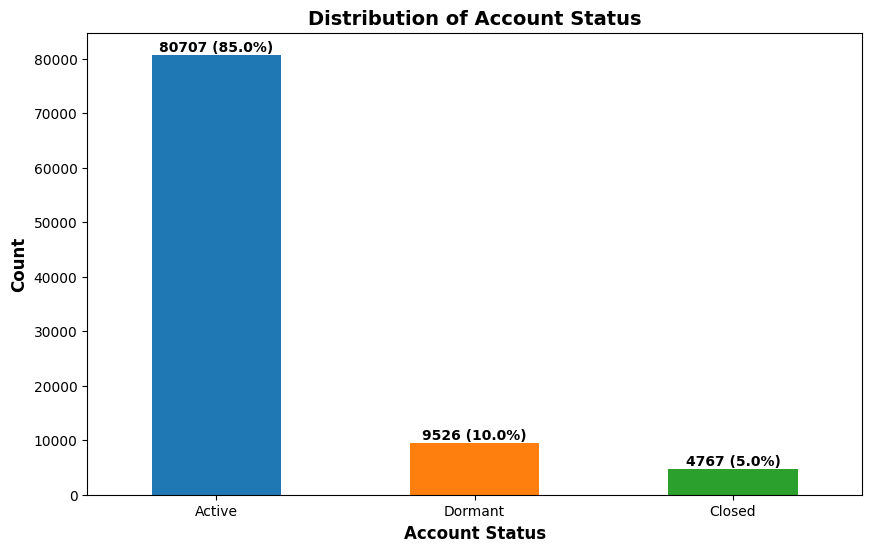

In [18]:
account_data['status'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'], figsize=(10, 6))

for i, (bar, label) in enumerate(zip(account_data['status'].value_counts().index, account_data['status'].value_counts().values)):
    plt.text(i, label + 0.5, f'{label} ({label / account_data.shape[0] * 100:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel('Account Status', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Account Status', fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

Duration indicates how long a person has been a bank customer

In [19]:
account_data['duration'] = pd.Timestamp.now() - pd.to_datetime(account_data['open_date'])

In [20]:
account_data

,account_id,customer_id,branch_id,account_type,balance,open_date,status,duration
0,1,11749,141,Current,95902.00,2019-10-20,Active,2481 days 08:12:57.486916
1,2,47716,43,Current,13261.61,2026-02-03,Active,183 days 08:12:57.486916
2,3,56143,90,Savings,26495.92,2020-10-19,Active,2116 days 08:12:57.486916
3,4,29193,113,Salary,74682.72,2012-02-22,Active,5278 days 08:12:57.486916
4,5,49907,28,Current,40419.01,2007-01-03,Active,7154 days 08:12:57.486916
...,...,...,...,...,...,...,...,...
94995,94996,43366,38,Fixed Deposit,66228.51,2012-03-18,Closed,5253 days 08:12:57.486916
94996,94997,50856,12,Current,39854.55,2011-10-21,Active,5402 days 08:12:57.486916
94997,94998,8593,68,Current,9310.24,2021-03-22,Active,1962 days 08:12:57.486916
94998,94999,49233,107,Fixed Deposit,13110.16,2009-10-16,Active,6137 days 08:12:57.486916


In [21]:
account_data['duration'][account_data['status']=='Dormant'].agg(['mean', 'min', 'max'])

mean   4006 days 17:13:40.569007104
min         66 days 08:12:57.486916
max       7886 days 08:12:57.486916
Name: duration, dtype: timedelta64[ns]

In [22]:
account_data['duration'][account_data['status']=='Closed'].agg(['mean', 'min', 'max'])

mean   3986 days 08:56:27.430276608
min         67 days 08:12:57.486916
max       7882 days 08:12:57.486916
Name: duration, dtype: timedelta64[ns]

In [23]:
def join_customer_email_to_account_data(df):
    """
    Join customer email to account data based on customer_id.

    Parameters:
    df (DataFrame): The account data DataFrame.

    Returns:
    DataFrame: The account data DataFrame with an additional 'email' column.
    """
    return df.merge(customer_data[['customer_id', 'email']], on='customer_id', how='left')

In [24]:
joined_account_data = join_customer_email_to_account_data(account_data)

joined_account_data

,account_id,customer_id,branch_id,account_type,balance,open_date,status,duration,email
0,1,11749,141,Current,95902.00,2019-10-20,Active,2481 days 08:12:57.486916,customer11748@mailbank.com
1,2,47716,43,Current,13261.61,2026-02-03,Active,183 days 08:12:57.486916,customer47715@mailbank.com
2,3,56143,90,Savings,26495.92,2020-10-19,Active,2116 days 08:12:57.486916,customer56142@mailbank.com
3,4,29193,113,Salary,74682.72,2012-02-22,Active,5278 days 08:12:57.486916,customer29192@mailbank.com
4,5,49907,28,Current,40419.01,2007-01-03,Active,7154 days 08:12:57.486916,customer49906@mailbank.com
...,...,...,...,...,...,...,...,...,...
94995,94996,43366,38,Fixed Deposit,66228.51,2012-03-18,Closed,5253 days 08:12:57.486916,customer43365@mailbank.com
94996,94997,50856,12,Current,39854.55,2011-10-21,Active,5402 days 08:12:57.486916,customer50855@mailbank.com
94997,94998,8593,68,Current,9310.24,2021-03-22,Active,1962 days 08:12:57.486916,customer8592@mailbank.com
94998,94999,49233,107,Fixed Deposit,13110.16,2009-10-16,Active,6137 days 08:12:57.486916,customer49232@mailbank.com


Both of these initiatives are aimed at re-engaging bank customers through email communication

In [25]:
joined_account_data[joined_account_data['status'] == 'Closed']['email'].value_counts().index.to_list()

['customer33179@mailbank.com',
 'customer2656@mailbank.com',
 'customer46181@mailbank.com',
 'customer52988@mailbank.com',
 'customer46527@mailbank.com',
 'customer23160@mailbank.com',
 'customer11172@mailbank.com',
 'customer46912@mailbank.com',
 'customer58108@mailbank.com',
 'customer38636@mailbank.com',
 'customer9521@mailbank.com',
 'customer24565@mailbank.com',
 'customer44081@mailbank.com',
 'customer56584@mailbank.com',
 'customer38198@mailbank.com',
 'customer6141@mailbank.com',
 'customer58859@mailbank.com',
 'customer5900@mailbank.com',
 'customer45383@mailbank.com',
 'customer22059@mailbank.com',
 'customer9915@mailbank.com',
 'customer27266@mailbank.com',
 'customer57590@mailbank.com',
 'customer51144@mailbank.com',
 'customer51149@mailbank.com',
 'customer24252@mailbank.com',
 'customer50461@mailbank.com',
 'customer40548@mailbank.com',
 'customer18174@mailbank.com',
 'customer6794@mailbank.com',
 'customer33528@mailbank.com',
 'customer33790@mailbank.com',
 'customer3027

In [26]:
joined_account_data[joined_account_data['status'] == 'Dormant']['email'].value_counts().index.to_list()

['customer58357@mailbank.com',
 'customer6366@mailbank.com',
 'customer11636@mailbank.com',
 'customer35740@mailbank.com',
 'customer13325@mailbank.com',
 'customer57449@mailbank.com',
 'customer28491@mailbank.com',
 'customer3564@mailbank.com',
 'customer49045@mailbank.com',
 'customer32184@mailbank.com',
 'customer57953@mailbank.com',
 'customer829@mailbank.com',
 'customer28287@mailbank.com',
 'customer2447@mailbank.com',
 'customer17949@mailbank.com',
 'customer1380@mailbank.com',
 'customer42824@mailbank.com',
 'customer8204@mailbank.com',
 'customer4749@mailbank.com',
 'customer50675@mailbank.com',
 'customer40023@mailbank.com',
 'customer59182@mailbank.com',
 'customer52900@mailbank.com',
 'customer14926@mailbank.com',
 'customer6374@mailbank.com',
 'customer53223@mailbank.com',
 'customer46586@mailbank.com',
 'customer11165@mailbank.com',
 'customer3033@mailbank.com',
 'customer30342@mailbank.com',
 'customer3719@mailbank.com',
 'customer17807@mailbank.com',
 'customer15709@mai

### Section 3

Viewing and Finding Insight from Branch Data

In [27]:
branch_data

,branch_id,branch_name,city,state,opened_date,ifsc_code
0,1,Pune Branch 1,Pune,Maharashtra,2016-05-23,BNK0000000
1,2,Bhopal Branch 2,Bhopal,Madhya Pradesh,2002-01-13,BNK0000001
2,3,Lucknow Branch 3,Lucknow,Uttar Pradesh,2017-12-10,BNK0000002
3,4,Kolkata Branch 4,Kolkata,West Bengal,2002-05-04,BNK0000003
4,5,Kolkata Branch 5,Kolkata,West Bengal,2005-11-09,BNK0000004
...,...,...,...,...,...,...
145,146,Kochi Branch 2,Kochi,Kerala,2017-05-27,BNK0000145
146,147,Mumbai Branch 3,Mumbai,Maharashtra,2008-07-27,BNK0000146
147,148,Bengaluru Branch 4,Bengaluru,Karnataka,1998-07-04,BNK0000147
148,149,Kochi Branch 5,Kochi,Kerala,2002-07-22,BNK0000148


Checking missing values on the Branch data

<Figure size 1000x600 with 0 Axes>

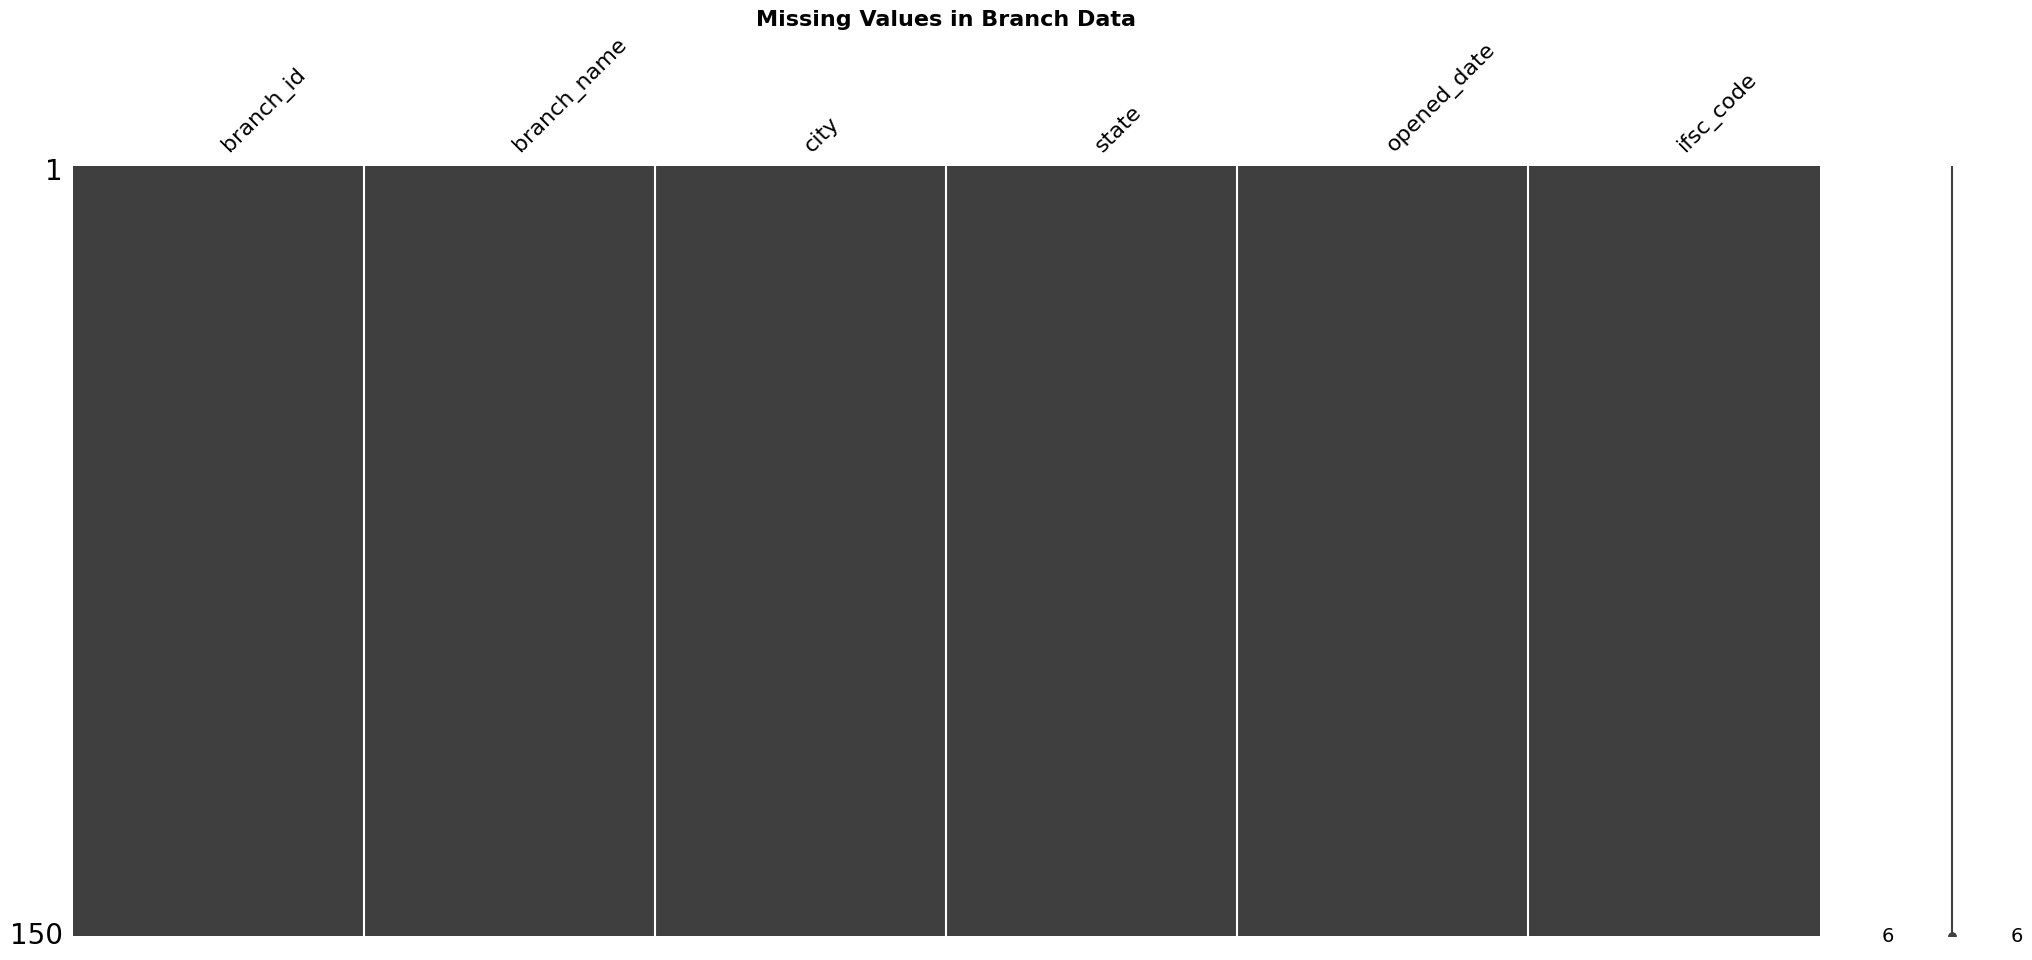

In [28]:
plt.figure(figsize=(10, 6))
msno.matrix(branch_data)
plt.title('Missing Values in Branch Data', fontsize=16, fontweight='bold')
plt.show()

In [29]:
branch_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   branch_id    150 non-null    int64 
 1   branch_name  150 non-null    object
 2   city         150 non-null    object
 3   state        150 non-null    object
 4   opened_date  150 non-null    object
 5   ifsc_code    150 non-null    object
dtypes: int64(1), object(5)
memory usage: 7.2+ KB


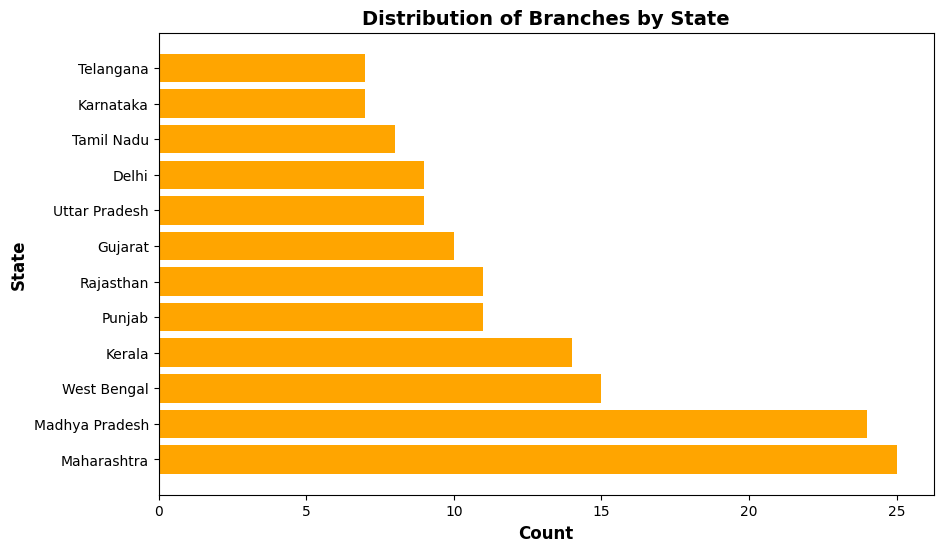

In [30]:
plt.figure(figsize=(10, 6))
plt.barh(branch_data['state'].value_counts().index, branch_data['state'].value_counts().values, color='orange')
plt.xlabel('Count', fontsize=12, fontweight='bold')
plt.ylabel('State', fontsize=12, fontweight='bold')
plt.title('Distribution of Branches by State', fontsize=14, fontweight='bold')
plt.show()

### Section 4

Viewing and Finding Insight from Loan Data

In [31]:
loan_data

,loan_id,customer_id,branch_id,loan_type,loan_amount,interest_rate,term_months,start_date,status
0,1,48019,129,Auto Loan,310670.27,9.54,60,2020-06-16,Active
1,2,47355,38,Education Loan,599321.65,16.20,12,2016-06-05,Active
2,3,30661,29,Gold Loan,135377.18,10.25,24,2012-07-03,Active
3,4,1755,66,Education Loan,20798.63,8.37,180,2013-01-27,Defaulted
4,5,18763,23,Education Loan,84367.97,8.97,60,2017-02-11,Active
...,...,...,...,...,...,...,...,...,...
21995,21996,53987,106,Business Loan,305636.98,9.02,84,2020-10-08,Active
21996,21997,13161,117,Personal Loan,1215540.98,14.12,36,2015-01-07,Defaulted
21997,21998,52751,41,Business Loan,29847.40,11.33,36,2016-04-21,Active
21998,21999,58299,7,Home Loan,263288.12,11.07,180,2025-03-10,Active


Checking missing values on the Loan data

<Figure size 1000x600 with 0 Axes>

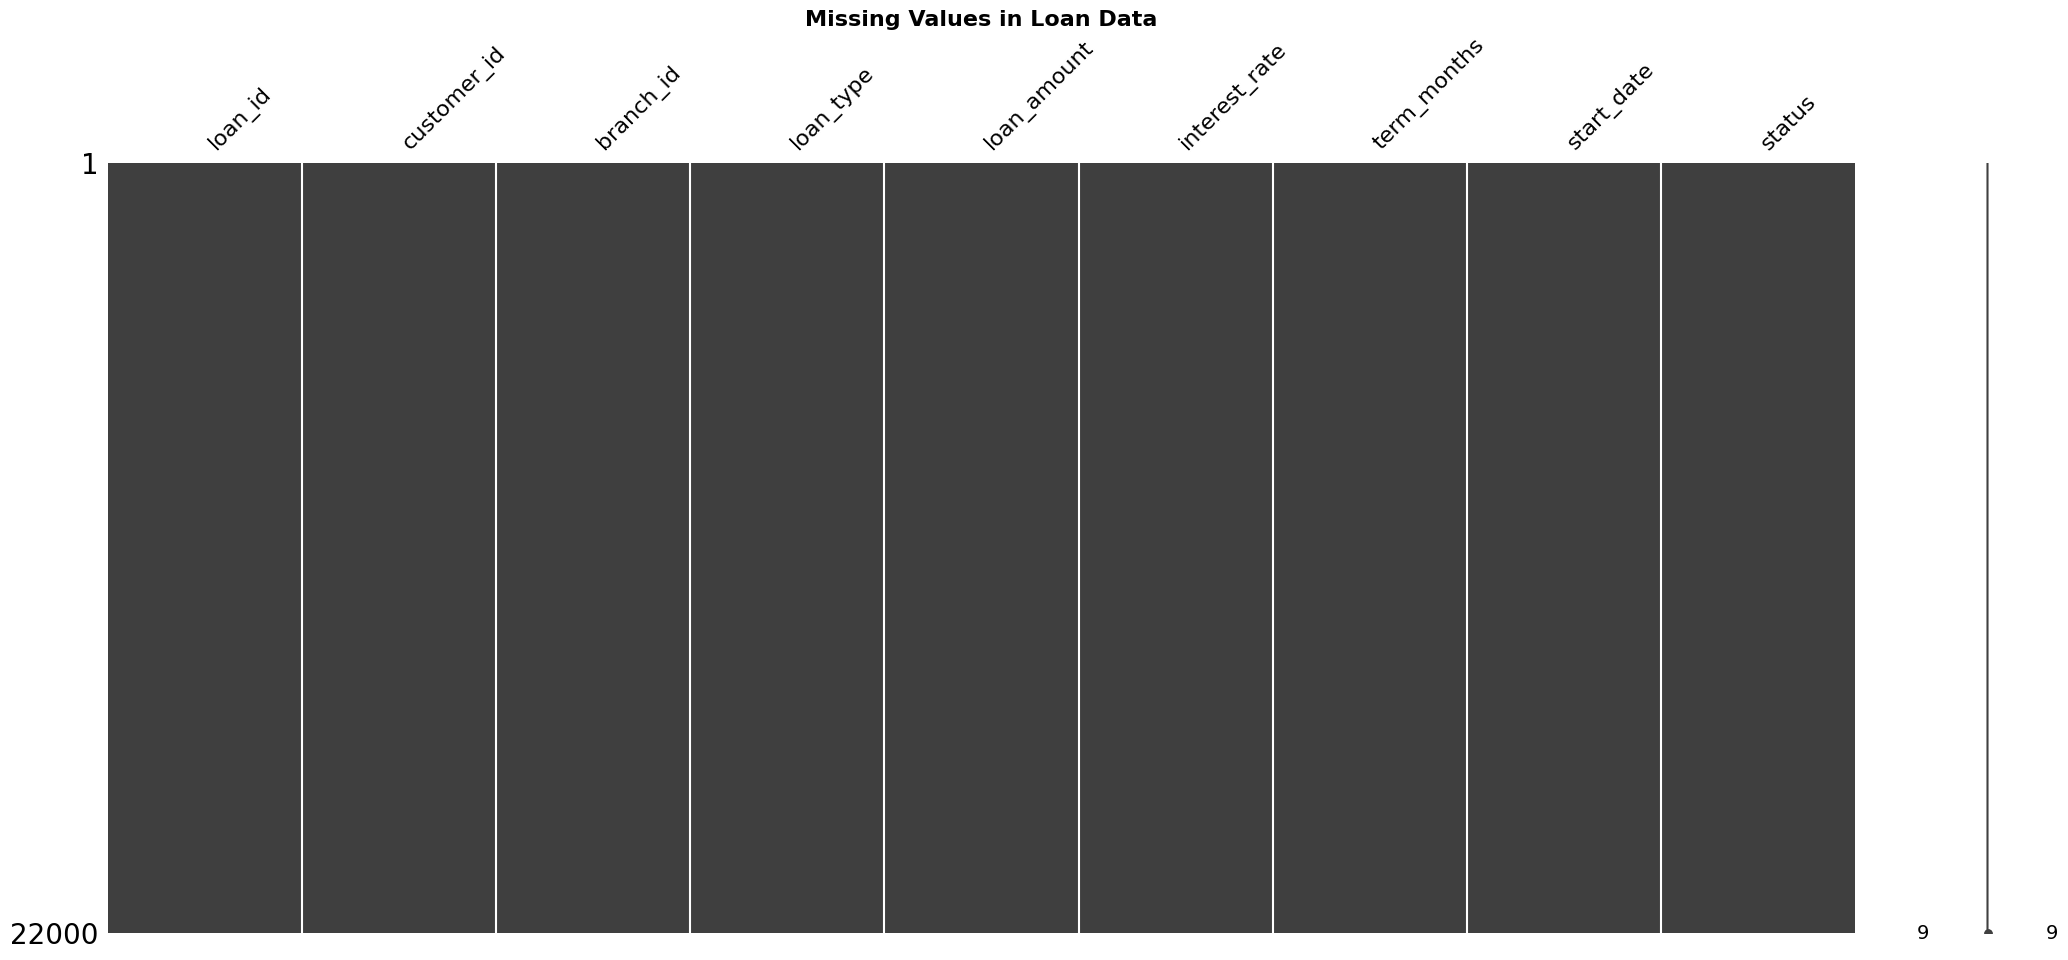

In [32]:
plt.figure(figsize=(10, 6))
msno.matrix(loan_data)
plt.title('Missing Values in Loan Data', fontsize=16, fontweight='bold')
plt.show()

In [33]:
def adding_customer_age_and_annual_income_to_loan_data(df):
    return df.merge(customer_data[['customer_id', 'Age', 'annual_income']], on='customer_id', how='left')

In [34]:
joined_loan_data = adding_customer_age_and_annual_income_to_loan_data(loan_data)

joined_loan_data

,loan_id,customer_id,branch_id,loan_type,loan_amount,interest_rate,term_months,start_date,status,Age,annual_income
0,1,48019,129,Auto Loan,310670.27,9.54,60,2020-06-16,Active,23,834373
1,2,47355,38,Education Loan,599321.65,16.20,12,2016-06-05,Active,51,2292243
2,3,30661,29,Gold Loan,135377.18,10.25,24,2012-07-03,Active,28,1243977
3,4,1755,66,Education Loan,20798.63,8.37,180,2013-01-27,Defaulted,72,3371552
4,5,18763,23,Education Loan,84367.97,8.97,60,2017-02-11,Active,28,1918243
...,...,...,...,...,...,...,...,...,...,...,...
21995,21996,53987,106,Business Loan,305636.98,9.02,84,2020-10-08,Active,63,3364186
21996,21997,13161,117,Personal Loan,1215540.98,14.12,36,2015-01-07,Defaulted,75,3408959
21997,21998,52751,41,Business Loan,29847.40,11.33,36,2016-04-21,Active,59,1644977
21998,21999,58299,7,Home Loan,263288.12,11.07,180,2025-03-10,Active,51,3463165


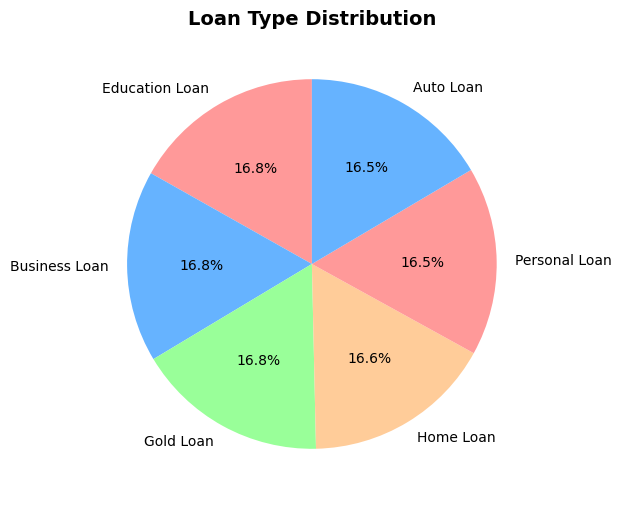

In [35]:
plt.figure(figsize=(10, 6))
plt.pie(joined_loan_data['loan_type'].value_counts(), labels=joined_loan_data['loan_type'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title('Loan Type Distribution', fontsize=14, fontweight='bold')
plt.show()

In [36]:
def adding_branch_name_to_loan_data(joined_loan_data, branch_data):
    # Merge the joined_loan_data with branch_data to add branch names
    merged_data = pd.merge(joined_loan_data, branch_data[['branch_id', 'branch_name']], on='branch_id', how='left')
    return merged_data

In [37]:
merged_loan_data = adding_branch_name_to_loan_data(joined_loan_data, branch_data)

merged_loan_data

,loan_id,customer_id,branch_id,loan_type,loan_amount,interest_rate,term_months,start_date,status,Age,annual_income,branch_name
0,1,48019,129,Auto Loan,310670.27,9.54,60,2020-06-16,Active,23,834373,Jaipur Branch 3
1,2,47355,38,Education Loan,599321.65,16.20,12,2016-06-05,Active,51,2292243,Kochi Branch 2
2,3,30661,29,Gold Loan,135377.18,10.25,24,2012-07-03,Active,28,1243977,Jaipur Branch 2
3,4,1755,66,Education Loan,20798.63,8.37,180,2013-01-27,Defaulted,72,3371552,Chennai Branch 3
4,5,18763,23,Education Loan,84367.97,8.97,60,2017-02-11,Active,28,1918243,Delhi Branch 5
...,...,...,...,...,...,...,...,...,...,...,...,...
21995,21996,53987,106,Business Loan,305636.98,9.02,84,2020-10-08,Active,63,3364186,Bhopal Branch 7
21996,21997,13161,117,Personal Loan,1215540.98,14.12,36,2015-01-07,Defaulted,75,3408959,Mumbai Branch 9
21997,21998,52751,41,Business Loan,29847.40,11.33,36,2016-04-21,Active,59,1644977,Delhi Branch 5
21998,21999,58299,7,Home Loan,263288.12,11.07,180,2025-03-10,Active,51,3463165,Pune Branch 7


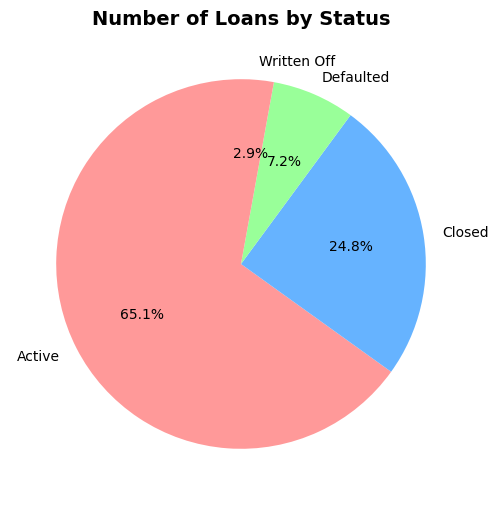

In [38]:
plt.figure(figsize=(10, 6))
plt.pie(merged_loan_data['status'].value_counts(), labels=merged_loan_data['status'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Number of Loans by Status', fontsize=14, fontweight='bold')
plt.show()

C:\Users\Vivo Design\AppData\Local\Temp\ipykernel_5188\2661519429.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_loan_data, x='branch_name', order=merged_loan_data['branch_name'].value_counts().index[:5], palette='viridis')


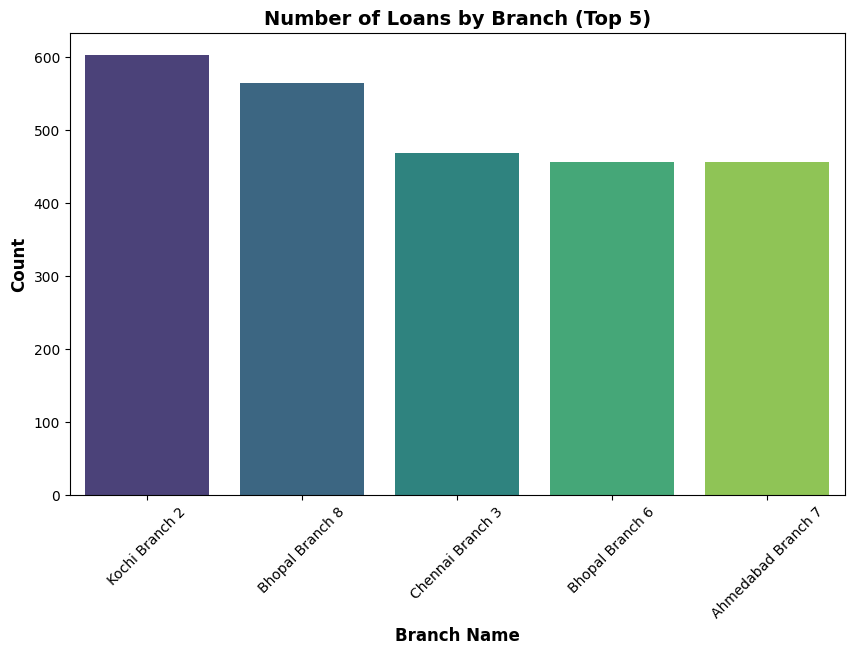

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_loan_data, x='branch_name', order=merged_loan_data['branch_name'].value_counts().index[:5], palette='viridis')
plt.xlabel('Branch Name', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Number of Loans by Branch (Top 5)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Section 5

Viewing and Finding Insight from Loan Payment Data

In [40]:
loan_payment_data

,payment_id,loan_id,payment_date,amount_paid,principal_component,interest_component,late_payment_flag
0,1,21070,05/06/2020,8144.05,5930.89,2213.16,0
1,2,17959,09/23/2011,6128.01,4406.78,1721.23,0
2,3,7239,02/25/2025,27946.17,25195.76,2750.41,0
3,4,9993,10/04/2015,5715.37,4082.41,1632.96,0
4,5,5487,07/26/2017,10119.72,9474.29,645.43,0
...,...,...,...,...,...,...,...
29995,29996,3847,06/13/2023,871.18,781.74,89.44,0
29996,29997,5104,01/31/2011,21669.75,19178.45,2491.30,0
29997,29998,5468,06/23/2022,9295.13,7319.87,1975.26,0
29998,29999,21247,03/24/2018,5752.49,4569.74,1182.75,0


In [41]:
def join_loan_amount_term_months_age_annual_income_to_loan_payment_data(df):
    return df.merge(merged_loan_data[['loan_id', 'loan_amount', 'term_months', 'Age', 'annual_income']], on='loan_id', how='left')

Master table for segmentation

In [42]:
joined_loan_payment_data = join_loan_amount_term_months_age_annual_income_to_loan_payment_data(loan_payment_data)

joined_loan_payment_data

,payment_id,loan_id,payment_date,amount_paid,principal_component,interest_component,late_payment_flag,loan_amount,term_months,Age,annual_income
0,1,21070,05/06/2020,8144.05,5930.89,2213.16,0,230776.77,180,71,1855882
1,2,17959,09/23/2011,6128.01,4406.78,1721.23,0,81758.03,12,50,622515
2,3,7239,02/25/2025,27946.17,25195.76,2750.41,0,327672.99,120,23,2217058
3,4,9993,10/04/2015,5715.37,4082.41,1632.96,0,814103.62,240,49,694410
4,5,5487,07/26/2017,10119.72,9474.29,645.43,0,509141.62,84,59,3076386
...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,3847,06/13/2023,871.18,781.74,89.44,0,271432.49,120,53,1556697
29996,29997,5104,01/31/2011,21669.75,19178.45,2491.30,0,45917.81,120,73,1941838
29997,29998,5468,06/23/2022,9295.13,7319.87,1975.26,0,142536.15,12,54,2259318
29998,29999,21247,03/24/2018,5752.49,4569.74,1182.75,0,298279.47,84,39,2423162


In [43]:
# Import the StandardScaler from sklearn.preprocessing
from sklearn.preprocessing import StandardScaler

seg_features = ['principal_component','interest_component','loan_amount','term_months','Age','annual_income']

scaler = StandardScaler()
seg_features_scaled = scaler.fit_transform(joined_loan_payment_data[seg_features])

print('Scaled shape:', seg_features_scaled.shape)

Scaled shape: (30000, 6)


### Section 6

#### Clustering for segmentation

Implementation clustering algorithms

Load library from sklearn

In [44]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import LocalOutlierFactor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.decomposition import PCA

Best k by silhouette: 2 (silhouette = 0.280)


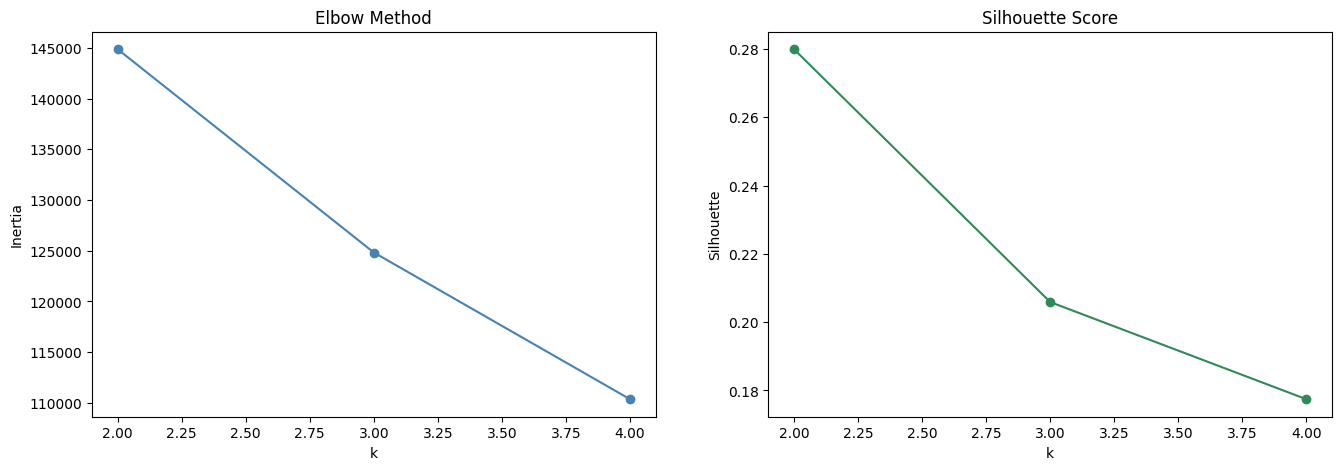

In [47]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

inertias, sils, K_range = [], [], range(2, 5)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=5, random_state=RANDOM_SEED)
    km.fit(seg_features_scaled)  
    inertias.append(km.inertia_)
    sils.append(silhouette_score(seg_features_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(K_range, sils, 'o-', color='seagreen')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette Score')
for c in sils:
    pass
best_k = K_range[int(np.argmax(sils))]
print(f'Best k by silhouette: {best_k} (silhouette = {max(sils):.3f})')

In [48]:
best_k = 3
km = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_SEED)
joined_loan_payment_data['Segment'] = km.fit_predict(seg_features_scaled)
print('Segment distribution:')
print(joined_loan_payment_data['Segment'].value_counts().sort_index())

Segment distribution:
Segment
0     4502
1    18806
2     6692
Name: count, dtype: int64


In [49]:
results = {}
for name, algo in [
    ('KMeans(k=3)', KMeans(n_clusters=3, n_init=20, random_state=RANDOM_SEED)),
    ('Agglomerative(k=4)', AgglomerativeClustering(n_clusters=4))
]:
    labels = algo.fit_predict(seg_features_scaled[0:10000])
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters >= 3:
        sil = silhouette_score(seg_features_scaled[0:10000], labels)
    else:
        sil = np.nan
    results[name] = {'n_clusters': n_clusters, 'silhouette': sil, 'labels': labels}
    print(f'{name}: {n_clusters} clusters, silhouette={sil:.3f}')

KMeans(k=3): 3 clusters, silhouette=0.206
Agglomerative(k=4): 4 clusters, silhouette=0.173


In [54]:
# 7.5 Cluster profile
profile = joined_loan_payment_data.groupby('Segment').agg(
    annual_income = ('annual_income', 'mean'),
    loan_amount = ('loan_amount', 'mean')
).round(2)
display(profile)

# Persona naming based on profile
personas = {}
for s in profile.index:
    row = profile.loc[s]
    if row['annual_income'] > profile['annual_income'].quantile(0.75):
        personas[s] = 'High Income Customers and High-Potential Performing Loans'
    elif row['annual_income'] < profile['annual_income'].quantile(0.50):
        personas[s] = 'Middle Income Customers and Medium-Potential Performing Loans'
    else:
        personas[s] = 'Low Income Customers and Risky-Potential Performing Loans'

joined_loan_payment_data['Persona'] = joined_loan_payment_data.Segment.map(personas)
print('\nPersona mapping:')
for k,v in personas.items(): print(f'  Segment {k}: {v}')

,annual_income,loan_amount
Segment,,
0,1835988.44,410414.44
1,1831723.23,420445.33
2,1836842.99,412841.47



Persona mapping:
  Segment 0: Low Income Customers and Risky-Potential Performing Loans
  Segment 1: Middle Income Customers and Medium-Potential Performing Loans
  Segment 2: High Income Customers and High-Potential Performing Loans


Computing t-SNE (this takes a few seconds)...


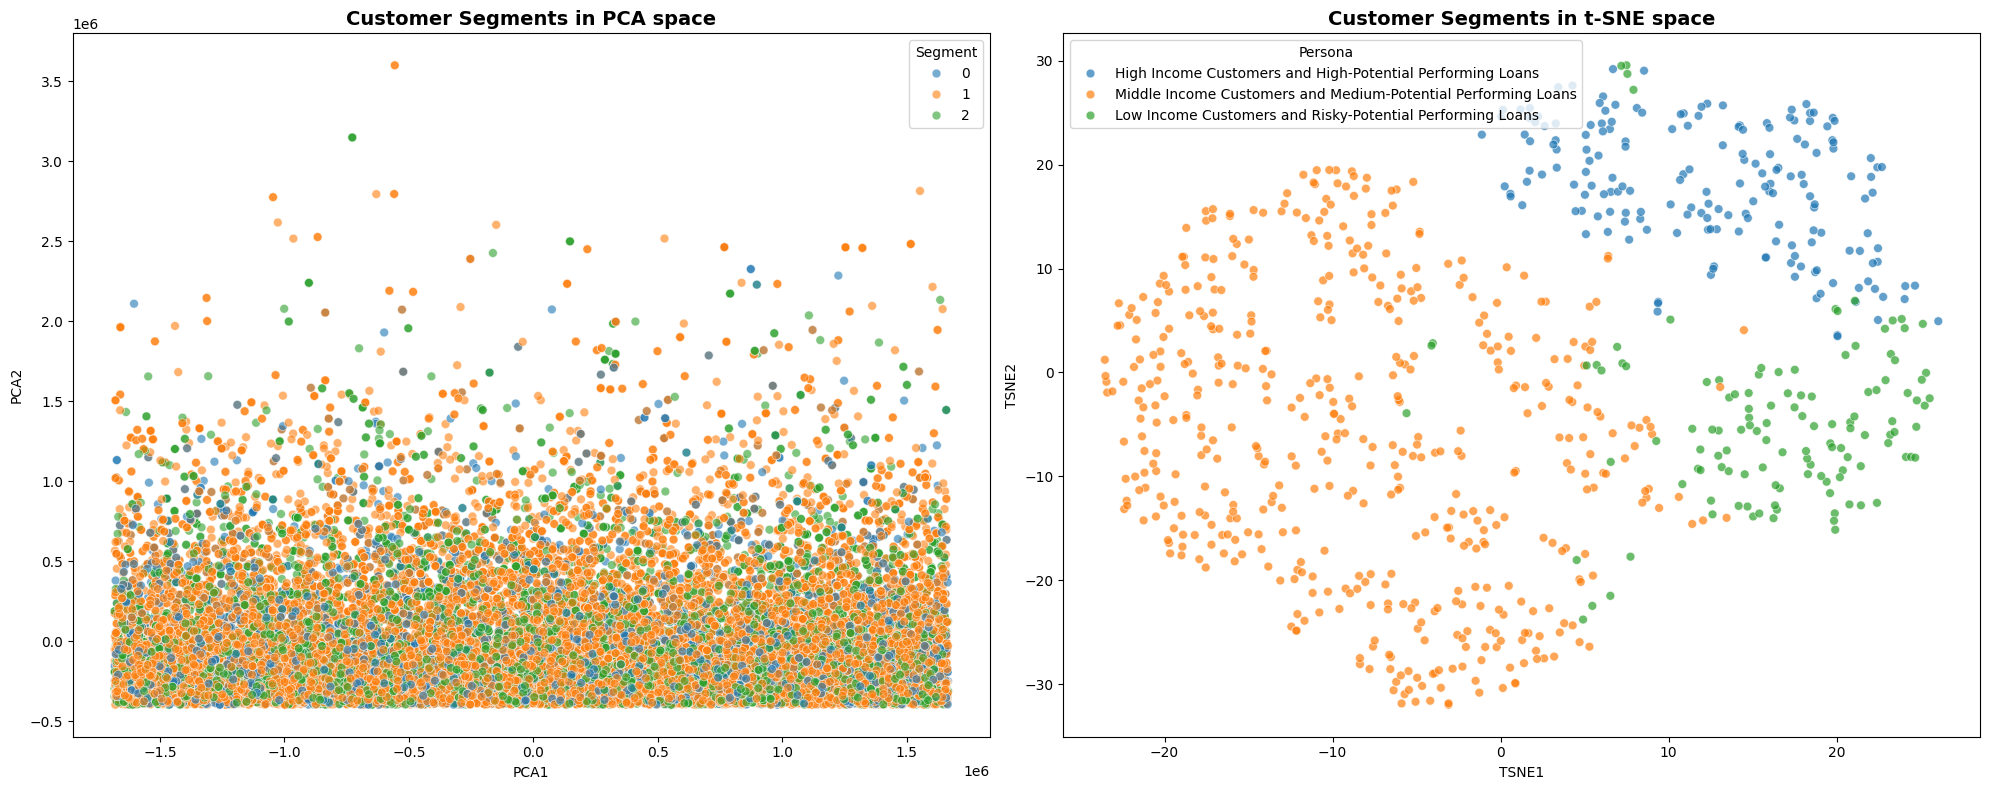

In [55]:
# 7.6 2D visualization with PCA

pca = PCA(n_components=2, random_state=RANDOM_SEED)
seg_2d = pca.fit_transform(joined_loan_payment_data[seg_features])
joined_loan_payment_data['PCA1'] = seg_2d[:,0]; joined_loan_payment_data['PCA2'] = seg_2d[:,1]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.scatterplot(data=joined_loan_payment_data, x='PCA1', y='PCA2', hue='Segment', palette='tab10',
                ax=axes[0], alpha=0.6, s=40)
axes[0].set_title('Customer Segments in PCA space', fontsize=14, fontweight='bold')

# t-SNE for more sensitive 2D
from sklearn.manifold import TSNE
print('Computing t-SNE (this takes a few seconds)...')
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, max_iter=600)
tsne_2d = tsne.fit_transform(seg_features_scaled[:800])  # subset for speed
tsne_df = pd.DataFrame(tsne_2d, columns=['TSNE1','TSNE2'])
tsne_df['Segment'] = joined_loan_payment_data['Segment'].values[:800]
tsne_df['Persona'] = tsne_df['Segment'].map(personas)
sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='Persona', palette='tab10',
                ax=axes[1], alpha=0.7, s=40)
axes[1].set_title('Customer Segments in t-SNE space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Proxy XGB accuracy: 0.997


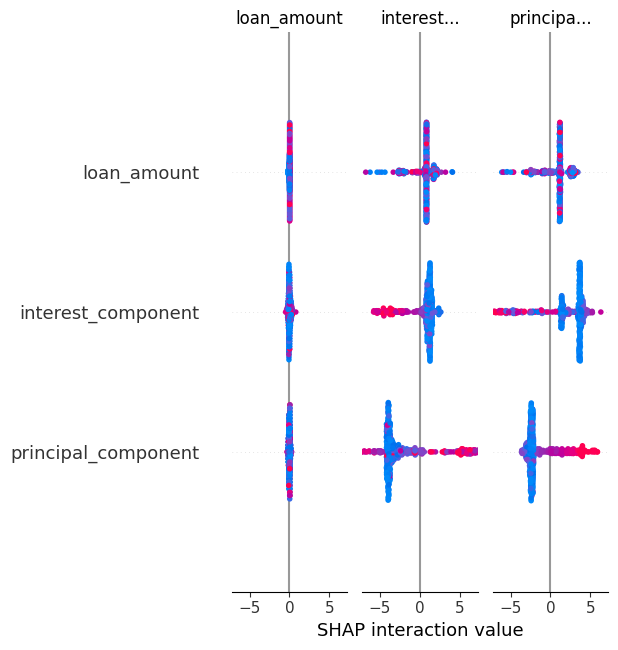

In [56]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import shap

proxy_features = seg_features
proxy_X = joined_loan_payment_data[proxy_features].fillna(joined_loan_payment_data[proxy_features].median())
proxy_y = joined_loan_payment_data['Segment']

X_tr, X_te, y_tr, y_te = train_test_split(proxy_X, proxy_y, test_size=0.3, random_state=RANDOM_SEED, stratify=proxy_y)
xgb_proxy = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.08,
                          random_state=RANDOM_SEED, n_jobs=-1, eval_metric='mlogloss')
xgb_proxy.fit(X_tr, y_tr)
print(f'Proxy XGB accuracy: {xgb_proxy.score(X_te, y_te):.3f}')

# SHAP - subsample for speed
explainer = shap.TreeExplainer(xgb_proxy)
X_te_sample = X_te.sample(min(500, len(X_te)), random_state=RANDOM_SEED)
shap_values = explainer.shap_values(X_te_sample)

# Plot SHAP summary for class 0 (highest-revenue segment)
if isinstance(shap_values, list):
    # shap_values is a list of arrays for each class
    sv = shap_values[0]
    base = explainer.expected_value[0]
else:
    sv = shap_values
    base = explainer.expected_value

# SHAP summary plot (full test set)
shap.summary_plot(sv, X_te_sample, show=False, plot_size=(10,6))
plt.tight_layout()
plt.show()

Replacing segment with true category

In [57]:
joined_loan_payment_data['Segment'].replace({'0': 'Middle Income', '1':'Low Income', '2':'High Income'}, inplace=True)

In [58]:
joined_loan_payment_data

,payment_id,loan_id,payment_date,amount_paid,principal_component,interest_component,late_payment_flag,loan_amount,term_months,Age,annual_income,Segment,Persona,PCA1,PCA2
0,1,21070,05/06/2020,8144.05,5930.89,2213.16,0,230776.77,180,71,1855882,2,High Income Customers and High-Potential Perfo...,2.237422e+04,-186467.268895
1,2,17959,09/23/2011,6128.01,4406.78,1721.23,0,81758.03,12,50,622515,1,Middle Income Customers and Medium-Potential P...,-1.210995e+06,-335470.550872
2,3,7239,02/25/2025,27946.17,25195.76,2750.41,0,327672.99,120,23,2217058,0,Low Income Customers and Risky-Potential Perfo...,3.835523e+05,-89576.346955
3,4,9993,10/04/2015,5715.37,4082.41,1632.96,0,814103.62,240,49,694410,2,High Income Customers and High-Potential Perfo...,-1.139091e+06,396874.155093
4,5,5487,07/26/2017,10119.72,9474.29,645.43,0,509141.62,84,59,3076386,1,Middle Income Customers and Medium-Potential P...,1.242882e+06,91882.221292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,3847,06/13/2023,871.18,781.74,89.44,0,271432.49,120,53,1556697,1,Middle Income Customers and Medium-Potential P...,-2.768105e+05,-145807.584888
29996,29997,5104,01/31/2011,21669.75,19178.45,2491.30,0,45917.81,120,73,1941838,0,Low Income Customers and Risky-Potential Perfo...,1.083285e+05,-371327.844355
29997,29998,5468,06/23/2022,9295.13,7319.87,1975.26,0,142536.15,12,54,2259318,1,Middle Income Customers and Medium-Potential P...,4.258092e+05,-274712.977314
29998,29999,21247,03/24/2018,5752.49,4569.74,1182.75,0,298279.47,84,39,2423162,1,Middle Income Customers and Medium-Potential P...,5.896550e+05,-118971.582261


C:\Users\Vivo Design\AppData\Local\Temp\ipykernel_5188\1539991940.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=joined_loan_payment_data, x='Persona', order=joined_loan_payment_data['Persona'].value_counts().index, palette='Set2')


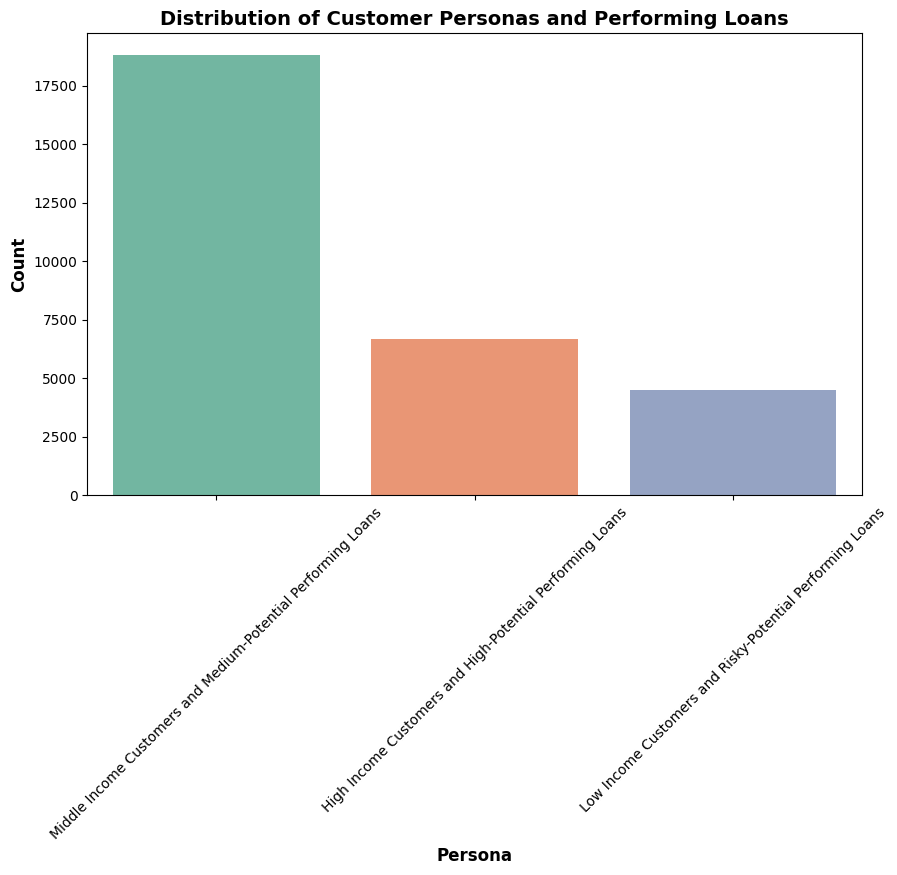

In [59]:
plt.figure(figsize=(10, 6))
sns.countplot(data=joined_loan_payment_data, x='Persona', order=joined_loan_payment_data['Persona'].value_counts().index, palette='Set2')
plt.xlabel('Persona', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Customer Personas and Performing Loans', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=10)
plt.show()

### Section 7

Visualizing with Streamlit (Gradio fail to be deployed)

In [60]:
from pathlib import Path
import pickle


import streamlit as st

BASE_DIR = Path.cwd()
MODEL_DIR = BASE_DIR / "deployment" / "models"

FEATURES = [
    "principal_component",
    "interest_component",
    "loan_amount",
    "term_months",
    "Age",
    "annual_income",
]

features_path = MODEL_DIR / "features.pkl"
if features_path.exists():
    with open(features_path, "rb") as f:
        FEATURES = pickle.load(f)

with open(MODEL_DIR / "kmeans.pkl", "rb") as f:
    kmeans_seg = pickle.load(f)

with open(MODEL_DIR / "personas.pkl", "rb") as f:
    personas_seg = pickle.load(f)

SEGMENT_DESC = {
    0: "Middle Income Customers and Medium-Potential Performing Loans",
    1: "Low Income Customers and Risky-Potential Performing Loans",
    2: "High Income Customers and High-Potential Performing Loans",
}

SCALER_PATH = MODEL_DIR / "scaler.pkl"
scaler = None
if SCALER_PATH.exists():
    with open(SCALER_PATH, "rb") as f:
        scaler = pickle.load(f)


def predict_segment(principal_component, interest_component, loan_amount, term_months, age, annual_income):
    input_df = np.array(
        [[principal_component, interest_component, loan_amount, term_months, age, annual_income]],
        dtype=float,
    )

    if scaler is not None:
        input_df = scaler.transform(input_df)

    segment = int(kmeans_seg.predict(input_df)[0])
    persona = personas_seg.get(segment, "Unknown persona")
    return segment, persona


st.set_page_config(page_title="Loan Customer Segmentation", page_icon="🏦", layout="centered")
st.title("Loan Customer Segmentation Dashboard")
st.write("Enter the customer attributes below to predict the loan customer segment.")

with st.form("segment_form"):
    col1, col2 = st.columns(2)

    with col1:
        principal_component = st.number_input("Principal Component", value=0.0, step=0.1)
        interest_component = st.number_input("Interest Component", value=0.0, step=0.1)
        loan_amount = st.number_input("Loan Amount", min_value=0.0, value=1000000.0, step=1000.0)

    with col2:
        term_months = st.number_input("Term Months", min_value=1, value=12, step=1)
        age = st.number_input("Age", min_value=18, value=30, step=1)
        annual_income = st.number_input("Annual Income", min_value=0.0, value=50000.0, step=1000.0)

    submitted = st.form_submit_button("Predict Segment")

if submitted:
    segment, persona = predict_segment(
        principal_component=principal_component,
        interest_component=interest_component,
        loan_amount=loan_amount,
        term_months=term_months,
        age=age,
        annual_income=annual_income,
    )

    st.success(f"Predicted Segment: {segment}")
    st.info(f"Persona: {persona}")
    st.write("Segment Description:")
    st.write(SEGMENT_DESC.get(segment, "Unknown segment"))

st.caption("This app expects the following saved model artifacts in the deployment/models folder:")
st.code("features.pkl\nkmeans.pkl\npersonas.pkl")

2026-08-05 08:24:28.648 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-05 08:24:28.648 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-05 08:24:31.464 
  command:

    streamlit run c:\Users\Vivo Design\AppData\Local\Programs\Python\Python310\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-08-05 08:24:31.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-05 08:24:31.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-05 08:24:31.480 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-05 08:24:31.480 Thread 'MainThread': missing ScriptRunContext! T

DeltaGenerator(_form_data=FormData(form_id='segment_form'))

Copy to your browser this link to be accessed: cust-segmentation-new.streamlit.app